# <font color='ff006e'>Where Should I Live? #

### Programming for Data Science Project | 2025-2026 ###
**Group 17** - Ana Silva (20241822), Beatriz Alves (20241747), Inês Claro (20241760)

**GitHub repository** - https://github.com/amdbsilva/Programming-for-Data-Science-Project

### <font color='ff006e'>Table of Contents </font>

- [1. Project Description](#project-description) 
- [2. Data Wrangling and Analysis](#data-wrangling-and-analysis)
    - [2.1. Data Visualization](#data-visualization)
- [3. Advanced Topic - Building an Interactive Map](#advanced-topic-building-an-interactive-map)
    - [3.1. Web Scrapping](#web-scraping)
    - [3.2. Interactive Map](#interactive-map)
- [4. Data Science in Action](#data-science-in-action)

<a id="project-description"></a>
### <font color='ff006e'>Project Description</font>

This project aims to assist individuals in the decision-making process regarding where to live in Europe by analysing country related data trough **Data Wrangling**, **Exploratory Analysis** and **Visualisation Techniques**. This way, individuals can assess the insights provided and evaluate them based on their own personal interests and priorities, facilitating more informed decisions. 

<a id="data-wrangling-and-analysis"></a>
### <font color='ff006e'>Data Wrangling and Analysis</font>

**Step 1:** Import all the libraries needed.

In [70]:
# data handling
import pandas as pd #2.3.2
import numpy as np #2.3.3
from datetime import datetime
import time
import re
import warnings
warnings.filterwarnings('ignore')

# visualisation
import matplotlib.pyplot as plt #3.10.6
import seaborn as sns #0.13.2
import plotly.express as px #6.3.0
import plotly.graph_objects as go

# scaling
from sklearn.preprocessing import MinMaxScaler #1.7.2

# web app framework
import dash #2.14.2
from dash import Dash, dcc, html, Input, Output, State
import webbrowser
from threading import Timer

# widgets and display
import ipywidgets as widgets #8.1.7
from IPython.display import display #9.1.0


# web scraping
from selenium import webdriver #4.38.0
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options as Options_c
from selenium.common.exceptions import NoSuchElementException

# python version 3.13.7

**Step 2:** Import the file *city_data.csv* to the variable *original_data*. By analysing the file, it is possible to see that the separator is a vertical bar (|) and that the relevant header is in the first row and that the actual header of the file is not needed (*Unnamed* row). Additionaly, it is possible to see that the last column of our dataset (`Last Data Update`) is a date, so the file can be imported with this specification.

In [71]:
original_data = pd.read_csv(r"city_data.csv", sep ="|", header = 1, parse_dates = ["Last Data Update"])
original_data

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,"Stockholm, Sweden",334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,NaN,2024-09-11
82,"Gothenburg, Sweden",245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,NaN,2023-03-10
83,"Malmo, Sweden",368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,NaN,2024-07-07
84,"Ankara, Turkiye",1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,309.0,2023-06-08


**Step 3:** Create a copy of the original dataset and analyse it. This step is essencial to ensure that any mistakes made during the data preprocessing phase do not affect the original dataset.

In [72]:
data_copy = original_data.copy()
data_copy.head()

,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17


In [73]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   City                             86 non-null     object        
 1   Population Density               85 non-null     float64       
 2   Population                       86 non-null     int64         
 3   Working Age Population           85 non-null     float64       
 4   Youth Dependency Ratio           86 non-null     float64       
 5   Unemployment Rate                85 non-null     float64       
 6   GDP per Capita                   85 non-null     float64       
 7   Days of very strong heat stress  86 non-null     int64         
 8   Main Spoken Languages            85 non-null     object        
 9   Average Monthly Salary           86 non-null     int64         
 10  Avgerage Rent Price              86 non-null     int64         


In [74]:
data_copy.rename(columns={'Avgerage Rent Price': 'Average Rent Price', 'Working Age Population ':'Working Age Population'}, inplace=True)

By using the `info` method, it is possible to check the number of rows, columns, missing values and data types of our dataset. We conclude there are 6 columns with missing values (`Population Density` (1), `Working Age Population` (1), `Unemployment Rate`(1), `GDP per Capita` (1), `Main Spoken Languages` (1) and `Average Price Groceries` (80)). We also noticed that the DataFrame had a typo in the column `Average Rent Price` and an extra blank space in `Working Age Population`, so we corrected it.

**Step 4:** Correct some errors in the dataset, so that it is uniform throughout all the rows.

**4.1**: Replace the separators in the columns `City` and `Main Spoken Languages`, so that all separators are commas.

In [75]:
data_copy['City'] = data_copy['City'].str.replace('.',',', regex = False)
data_copy['City'] = data_copy['City'].str.replace(';',',', regex = False)
data_copy['Main Spoken Languages'] = data_copy['Main Spoken Languages'].str.replace(';',',')

**4.2**: Split the column `City` into `Country` and `City` and remove any unnecessary white spaces in this columns' data. For convenience, the order of these 2 columns was also switched.

In [76]:
#split the column City in two: the column City and the column Country
data_copy[['City', 'Country']] = data_copy['City'].str.split(',', expand=True)

#remove unnecessary white spaces in the columns' data
data_copy['City'] = data_copy['City'].apply(lambda x: x.strip())
data_copy['Country'] = data_copy['Country'].apply(lambda x: x.strip())

#switch the order they appear on the dataset
country_col = data_copy.pop('Country')
data_copy.insert(0,'Country', country_col)
data_copy.head()

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,Austria,Vienna,310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15
1,Austria,Salzburg,243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03
2,Belgium,Brussels,681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22
3,Belgium,Antwerp,928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09
4,Belgium,Gent,552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17


**Step 5**: Fill in the missing value (MCAR - Missing Completely at Random missing value) in the column `Main Spoken Languages` with the associated country's mode and normalize the data in that column by removing unnecessary white spaces.

In [77]:
data_copy['Main Spoken Languages'] = (data_copy.groupby('Country')['Main Spoken Languages'].transform(
                                    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else 'Unknown'))
data_copy['Main Spoken Languages'] = data_copy['Main Spoken Languages'].apply(lambda x: x.strip())

**Step 6**: Impute missing values in the columns `Population Density`, `Working Age Population`, `GDP per Capita` and `Unemployment Rate`. For these, since the missing values are MCAR (Missing Completely at Random) and the variables are numerical, the missing entries will be filled with the median value of the associated country. The median was preferred over the mean since it is less sensitive to outliers.

In [78]:
for column in ['Population Density', 'Working Age Population', 'GDP per Capita', 'Unemployment Rate']:
    data_copy[column] = data_copy.groupby('Country')[column].transform(lambda x: x.fillna(x.median()))

**Step 7:** Remove the column `Average Price Groceries`. This column will be removed since the majority of its entries (93%) is missing, meaning it does not provide any meaningful information.

In [79]:
data_copy = data_copy.drop(columns = "Average Price Groceries", axis = 1)
data_copy.head()

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,Austria,Vienna,310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15
1,Austria,Salzburg,243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,2023-11-03
2,Belgium,Brussels,681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22
3,Belgium,Antwerp,928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09
4,Belgium,Gent,552.0,645813,417832.0,24.8,6.2,53311.0,2,"Dutch, French",2400,827,1200,2023-07-17


**NOTE**: All missing values have been imputed, meaning the dataset is complete and can be used for further analysis.

**Step 8:** Handle the **data inconsistency** in the 46th row of the dataset: the City and Country entries are swapped.

In [80]:
data_copy["Country"].unique() 

array(['Austria', 'Belgium', 'Bulgaria', 'Switzerland', 'Cyprus',
       'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland',
       'France', 'United Kingdom', 'Athens', 'Greece', 'Croatia',
       'Hungary', 'Ireland', 'Italy', 'Luxembourg', 'Latvia', 'Malta',
       'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Slovak Republic', 'Slovenia', 'Sweden', 'Turkiye'], dtype=object)

In [81]:
data_copy.query("Country == 'Athens'")

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
45,Athens,Greece,1829.0,3530371,2287174.0,22.0,17.2,38580.0,17,"Greek, English",1050,600,1200,2024-07-16


Using the `unique()` and `query()` methods, it was identified that the values 'Athens' and 'Greece' were swapped. Therefore, this row will be manually corrected.

In [82]:
wrong_name = 45 
data_copy.loc[wrong_name, ['Country','City']] = data_copy.loc[wrong_name, ['City','Country']].values
data_copy.iloc[[45]] # check if the correction happened

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
45,Greece,Athens,1829.0,3530371,2287174.0,22.0,17.2,38580.0,17,"Greek, English",1050,600,1200,2024-07-16


**Step 9:** Search and drop duplicate rows.

In [83]:
data_copy[data_copy.duplicated()]

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
16,Germany,Berlin,304.0,5303922,3481212.0,21.3,4.7,46548.0,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29
33,Spain,Malaga,571.0,869096,585608.0,23.5,17.7,27694.0,0,"Spanish, English",2200,1312,1400,2023-11-27


In [84]:
data_copy.drop_duplicates(inplace=True)
data_copy[data_copy.duplicated()] # confirm all duplicates are dropped

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update


<div class="alert alert-block alert-info"> 

#### Question 1: How did you handle missing values and duplicate records in the dataset? Justify your approach.

Regarding missing values, they were detected using the `info()` method. The column `Average Price Groceries` was removed since it consisted mostly of missing values. The missing values in the columns `Population Density`, `Working Age Population`, `GDP per Capita` and `Unemployment Rate` were imputed using the median values for each country, and the missing values in `Main Spoken Languages` were imputed with the mode of the associated country. All duplicate records were identified in the dataset and removed.
</div>

**Step 10:** Find the number of countries and cities that exist in the dataset.

In [85]:
data_copy.describe(include = 'object')

,Country,City,Main Spoken Languages
count,84,84,84
unique,30,84,54
top,Germany,Vienna,Italian
freq,10,1,6


**NOTE**: There is a total of **30 countries** and **84 cities**. The most frequent country in the dataset is **Germany** (with 10 cities).

<div class="alert alert-block alert-info"> 

#### Question 2: a) Which country appears most frequently in the dataset? How many cities are associated with it?
The country that appears most frequently in the dataset is **Germany**, with **10 cities** associated with it.
</div>

**Step 11**: Group the number of cities by country to determine how many cities are associated with each country.

In [86]:
number_of_cities_per_country = data_copy.groupby("Country")["City"].count()
print(number_of_cities_per_country)
print(f"Greece is associated with {number_of_cities_per_country["Greece"]} cities")

Country
Austria             2
Belgium             4
Bulgaria            2
Croatia             2
Cyprus              2
Czechia             2
Denmark             2
Estonia             1
Finland             2
France              3
Germany            10
Greece              2
Hungary             3
Ireland             2
Italy               6
Latvia              1
Luxembourg          1
Malta               1
Netherlands         5
Norway              3
Poland              3
Portugal            4
Romania             1
Slovak Republic     1
Slovenia            1
Spain               5
Sweden              3
Switzerland         3
Turkiye             2
United Kingdom      5
Name: City, dtype: int64
Greece is associated with 2 cities


<div class="alert alert-block alert-info"> 

#### Question 2: b) How many cities are present in total? How many are associated with Greece?
There are **84 cities in total** and **2** of them are associated with **Greece**.
</div>

**Step 12**: Sort the columns `City` and `Country` alphabetically.

In [87]:
data_copy = data_copy.sort_values(by=['Country','City'], ignore_index = True)
data_copy

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,Austria,Salzburg,243.0,375489,250472.0,20.30,3.0,66689.0,0,German,3200,1100,2186,2023-11-03
1,Austria,Vienna,310.0,2983513,2018818.0,20.10,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15
2,Belgium,Antwerp,928.0,1139663,723396.0,27.70,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09
3,Belgium,Bruges,840.0,119765,74600.0,25.63,5.6,63083.0,0,"Dutch, French",2700,1250,1708,2023-10-25
4,Belgium,Brussels,681.0,3284548,2137425.0,27.50,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,527.0,907580,614959.0,23.40,3.7,54002.0,0,"English, Scots Gaelic",2500,1010,2050,2023-08-15
80,United Kingdom,Glasgow,548.0,1845020,1229657.0,24.20,4.8,39666.0,0,"English, Scots",2300,1050,1950,2023-05-28
81,United Kingdom,Leeds,517.0,2641062,1677791.0,30.00,3.5,37990.0,0,"English, Urdu",2300,1000,2000,2024-11-03
82,United Kingdom,Liverpool,1560.0,1544216,983056.0,26.80,7.5,33749.0,0,English,2250,950,1800,2024-01-23


**Step 13**: Create a new dataframe with the columns `Country` and `Main Spoken Languages` to calculate how many countries speak each language.

**13.1**: Separate the `Main Spoken Languages` so that each row corresponds to just one language. Remove any white spaces the column `Language`'s data might contain as well as duplicates, making each language appear only once.

In [88]:
languages = data_copy[['Country', 'Main Spoken Languages']].copy() # new dataframe with columns "Country" and "Main Spoken Languages"
languages['Language'] = languages['Main Spoken Languages'].str.split(',') # more than one language can be spoken by each country - separated by ',' in the dataset
languages = languages[['Country','Language']].explode('Language') # one language per row

languages['Language'] = languages['Language'].str.strip() # remove white spaces
languages.drop_duplicates(inplace=True) #remove duplicates

**13.2**: Count how many languages are spoken in each country (and group them by country) and store the result in the variable `count_languages_spoken`. Rename the count column to `Language Count` and sort the values so that the most spoken language appears first.

In [89]:
count_languages_spoken = languages.groupby(['Language']).count()['Country'] # count how many rows are associated w/ each language
count_languages_spoken = count_languages_spoken.to_frame(name = 'Language Count') # converts to a DataFrame
count_languages_spoken.sort_values('Language Count', ascending = False) # descending sorting

,Language Count
Language,
English,25
Turkish,5
German,4
French,4
Arabic,3
Russian,3
Greek,2
Polish,2
Dutch,2


**13.3**: Identify the least spoken languages.

In [90]:
least_spoken_languages = count_languages_spoken[count_languages_spoken['Language Count'] == count_languages_spoken['Language Count'].min()]
answer = ", ".join(least_spoken_languages.index.tolist()) # this intermediate step is done to print out the answer without []
print(f"The least spoken languages are {answer}.")

The least spoken languages are Bengali, Bulgarian, Catalan, Croatian, Czech, Danish, Estonian, Finnish, Hungarian, Irish Gaelic, Italian, Latvian, Luxembourgish, Maltese, Norwegian, Portuguese, Romanian, Scots, Scots Gaelic, Serbian, Slovak, Slovene, Spanish, Urdu, Valencian.


<div class="alert alert-block alert-info"> 

#### Question 2: c) Which is the least spoken language in the dataset? Which are the top 3 most spoken languages?
The 3 most spoken languages are **English** (25), **Turkish**(5), **German** and **French** (both have a count of 4, so there is a tie for 3rd place). The least spoken languages are the ones that have the minimum count value (1) - Slovak, Norwegian, Slovene, Spanish, Scots Gaelic, Scots, Urdu, Romanian, Portuguese, Serbian, Latvian, Maltese, Luxembourgish, Bengali, Italian, Irish Gaelic, Hungarian, Finnish, Estonian, Danish, Czech, Croatian, Catalan, Bulgarian and Valencian.
</div>

**Step 14**: Find out how many days ago was the last update for each city and which cities require an update (meaning which cities have entries that were uploaded prior to *April 2023*).

In [91]:
data_copy['Since Updated (in days)'] = (datetime.now() - data_copy['Last Data Update']).dt.days
cities_need_update = data_copy[data_copy['Last Data Update'] < '2023-04-01'] #check cities that the data wasn't updated before april 2023
city_list = cities_need_update['City'].tolist() #create list with cities that need to update data (data wasn't updated since april 2023)
answer = ", ".join(city_list) # this intermediate step is done to print out the answer without []
print(f"Cities that require an update: {answer}.")

Cities that require an update: Lyon, Frankfurt am Main, Munich, Venice, Gothenburg, Basel.


<div class="alert alert-block alert-info"> 

#### Question 3: a) Entries uploaded before April 2023 need to be updated. Which cities would require an update?
The cities that need to update their data are **Lyon**, **Frankfurt am Main**, **Munich**, **Venice**, **Gothenburg** and **Basel**.
</div>

<div class="alert alert-block alert-info"> 

#### Question 3: b) How many days ago was the last update? On what day, month, and year did it occur?
The answer to this question is provided in the following code cell.
</div>

**Step 15**: Create a new pandas Series that, for each city that needs to update their data, displays how many days ago the last update was as well as the exact day, month and year. 

In [92]:
cities_need_update_copy = cities_need_update.copy() # so the following code is not executed on all cities

cities_need_update_copy['Day'] = cities_need_update_copy['Last Data Update'].dt.day
cities_need_update_copy['Month'] = cities_need_update_copy['Last Data Update'].dt.strftime('%B') # to give the name of the month
cities_need_update_copy['Year'] = cities_need_update_copy['Last Data Update'].dt.year


for line in (cities_need_update_copy['City'].astype(str) + ": The last update was " + cities_need_update_copy['Since Updated (in days)'].astype(str)
    + " days ago, on the day " + cities_need_update_copy['Day'].astype(str)
    + " of " + cities_need_update_copy['Month'].astype(str)
    + " of the year " + cities_need_update_copy['Year'].astype(str)
    + "."):
    print(line) # a for loop is used here because otherwise pandas would print it in a Series format

Lyon: The last update was 996 days ago, on the day 31 of March of the year 2023.
Frankfurt am Main: The last update was 1051 days ago, on the day 4 of February of the year 2023.
Munich: The last update was 1011 days ago, on the day 16 of March of the year 2023.
Venice: The last update was 1004 days ago, on the day 23 of March of the year 2023.
Gothenburg: The last update was 1017 days ago, on the day 10 of March of the year 2023.
Basel: The last update was 1067 days ago, on the day 19 of January of the year 2023.


<a id="data-visualization"></a>
#### <font color='ff006e'>Data Visualization</font>

**Step 1:** Check how the `Unemployment Rate` and `GDP per Capita` variables are distributed and related.

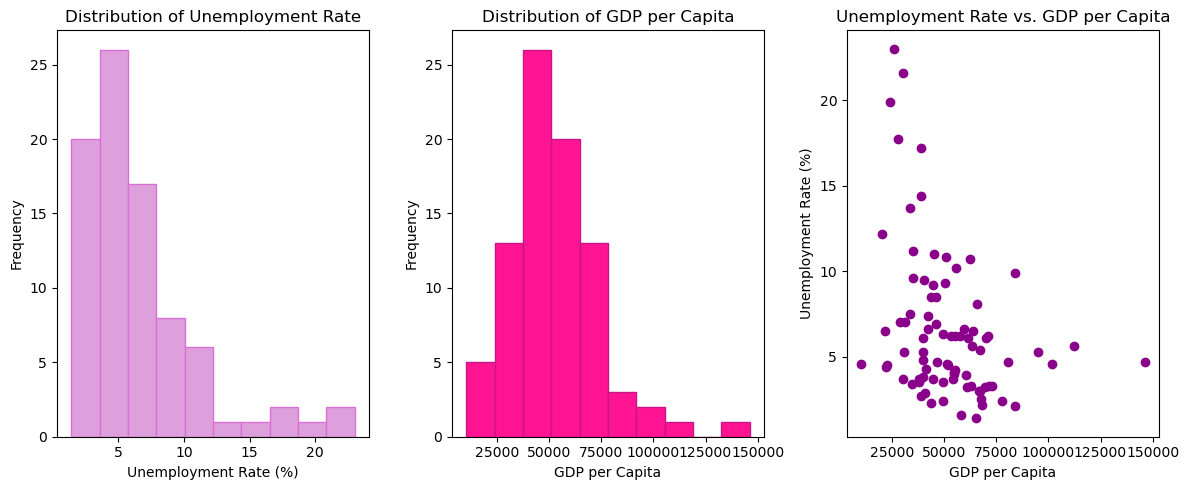

Correlation: -0.3466584086175857


In [93]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].hist(data_copy['Unemployment Rate'], color='plum', edgecolor='orchid')
axs[0].set_title('Distribution of Unemployment Rate')
axs[0].set_xlabel('Unemployment Rate (%)')
axs[0].set_ylabel('Frequency')

axs[1].hist(data_copy['GDP per Capita'], color='deeppink', edgecolor='mediumvioletred')
axs[1].set_title('Distribution of GDP per Capita')
axs[1].set_xlabel('GDP per Capita')
axs[1].set_ylabel('Frequency')

axs[2].scatter(data_copy['GDP per Capita'], data_copy['Unemployment Rate'], color = 'darkmagenta')
axs[2].set_title('Unemployment Rate vs. GDP per Capita')
axs[2].set_xlabel('GDP per Capita')
axs[2].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()  # prevents overlapping of subplots
plt.show()

correlation = data_copy['GDP per Capita'].corr(data_copy['Unemployment Rate']) # calculate correlation
print(f"Correlation: {correlation}")


<div class="alert alert-block alert-info"> 

#### Question 4: a) How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? 
Based on the first 2 graphs, it is noticeable that both `Unemployment Rate` and `GDP per Capita` are **right skewed** (`Unemployment Rate` more significantly than the latter), which indicates that while majority of the analysed cities have low `Unemployment Rate` and `GDP per Capita`, there are fewer cities that have higher values of these variables (skewing the distributions to the right). The last graph shows that these variables are **not highly correlated** (the observations are very sparse). WE can observe a **negative**, although **weak**, relation, which is confirmed with the calculated **correlation (-0.347)**. This relationship suggests that wealthier cities (with a high `GDP per Capita`) tend to have fewer unemployed citizens (have a low `Unemployment Rate`). However, since the coefficient is low, it might indicate that there are other factors that have a bigger influence in the `Unemployment Rate`, rather than the `GDP per Capita`. 
</div>

**Step 2**: Create a new column to store the difference between the `Average Monthly Salary` and the `Average Cost of Living` for each city.

In [94]:
data_copy['difference Avg. Monthly Salary and Avg. Cost of Living'] = data_copy['Average Monthly Salary'] - data_copy['Average Cost of Living']
data_copy.head()

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update,Since Updated (in days),difference Avg. Monthly Salary and Avg. Cost of Living
0,Austria,Salzburg,243.0,375489,250472.0,20.30,3.0,66689.0,0,German,3200,1100,2186,2023-11-03,779,1014
1,Austria,Vienna,310.0,2983513,2018818.0,20.10,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15,554,439
2,Belgium,Antwerp,928.0,1139663,723396.0,27.70,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,499,656
3,Belgium,Bruges,840.0,119765,74600.0,25.63,5.6,63083.0,0,"Dutch, French",2700,1250,1708,2023-10-25,788,992
4,Belgium,Brussels,681.0,3284548,2137425.0,27.50,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,974,1450


**Step 3**: Determine the top 5 cities with the largest difference.

In [95]:
top5cities = data_copy.sort_values(by = 'difference Avg. Monthly Salary and Avg. Cost of Living', ascending = False)[["City", "difference Avg. Monthly Salary and Avg. Cost of Living"]].head()
top5cities

,City,difference Avg. Monthly Salary and Avg. Cost of Living
74,Basel,2127
18,Tampere,1900
17,Helsinki,1850
76,Zurich,1774
75,Geneva,1531


<div class="alert alert-block alert-info"> 

#### Question 4: b) Which are the top 5 cities with the largest difference between the `Average Monthly Salary` and `Average Cost of Living`?
The 5 cities with the largest difference between the `Average Monthly Salary` and `Average Cost of Living` are **Basel** (€2127), **Tampere** (€1900), **Helsinki** (€1850), **Zurich** (€1774) and **Geneva** (€1531).
</div>

**Step 4**: Determine the top 5 countries with the smallest average difference.

In [96]:
bottom5countries = data_copy.groupby('Country')['difference Avg. Monthly Salary and Avg. Cost of Living'].mean().sort_values(ascending  = True).head()
bottom5countries.round(3)

Country
Portugal          -207.500
Greece            -125.000
Slovak Republic    -50.000
Turkiye            -25.000
Poland             -16.667
Name: difference Avg. Monthly Salary and Avg. Cost of Living, dtype: float64

<div class="alert alert-block alert-info"> 

#### Question 4: b) What about the top 5 countries with the smallest average difference?
The top 5 countries with the smallest average difference between the *Average Monthly Salary* and *Average Cost of Living* are **Portugal** (-€207.5), **Greece** (-€125), **SlovakRepublic** (-€50), **Turkiye** (-€25) and **Poland** (-€16.67).
</div>

**Step 5**: Provide a visual representation of the previous 2 results.

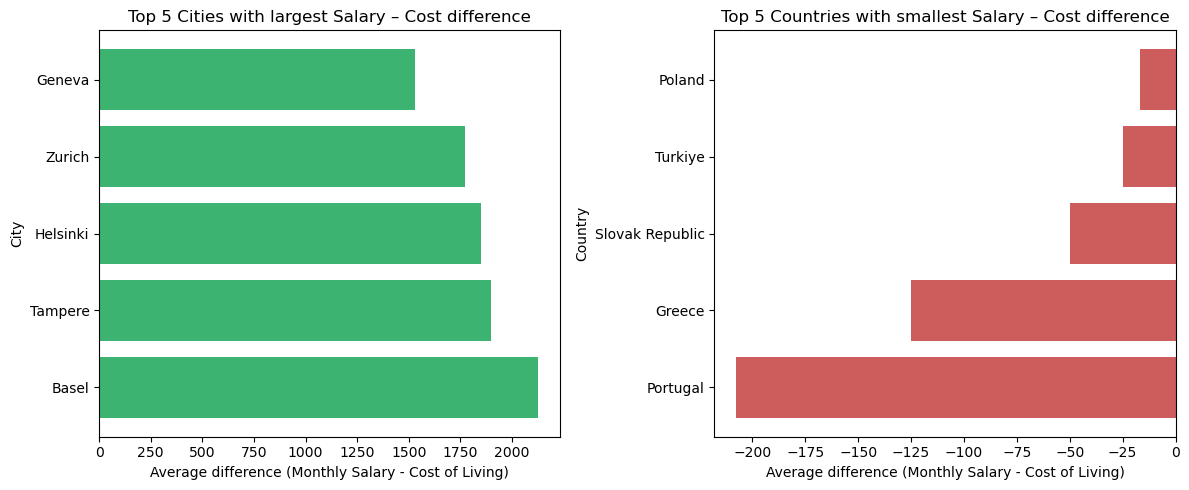

In [97]:
fig2, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].barh(top5cities["City"], top5cities["difference Avg. Monthly Salary and Avg. Cost of Living"], color='mediumseagreen')
axs[0].set_title('Top 5 Cities with largest Salary – Cost difference')
axs[0].set_xlabel('Average difference (Monthly Salary - Cost of Living)')
axs[0].set_ylabel('City')

axs[1].barh(bottom5countries.index, bottom5countries.values, color='indianred')
axs[1].set_title('Top 5 Countries with smallest Salary – Cost difference')
axs[1].set_xlabel('Average difference (Monthly Salary - Cost of Living)')
axs[1].set_ylabel('Country')

plt.tight_layout() # adjustment of space so elements do not overlap
plt.show()

The top 5 cities with the largest `Salary - Cost difference` all have money surpluses above 1250€, which suggest a high purchasing power for its citizens. It is worth noticing that 3 (Geneva, Zurich and Basel) out of the 5 cities are in Switzerland, meaning that this might be a favorable country to consider for individuals who prioritize a higher purchasing power.

The top 5 countries with the smallest `Salary - Cost difference` all have a negative difference, meaning the `Average Cost of Living` surpasses the `Average Monthly Salary`. This suggests a higher financial pressure for its citizens, since the earned salary is not enough to cover the expenses. Therefore, many individuals may refrain from living in those countries due to this unattractive factor.

**Step 6**: Determine the best city with specific characteristics:
- an `Average Monthly Salary` above €2000; 
- an `Average Cost of Living` below €1600;
- the lowest `Unemployment Rate` possible.

In [98]:
best_cities = data_copy[(data_copy['Average Monthly Salary'] > 2000) & 
                        (data_copy['Average Cost of Living'] <= 1600)].sort_values(
                            by = 'Unemployment Rate', ascending = True)

print(f"The best city for someone looking for those specific characteristics is {best_cities.iloc[0,1]}, {best_cities.iloc[0,0]}.")
data_copy[data_copy["City"] == best_cities.iloc[0,1]][['Country','City','Average Monthly Salary','Average Cost of Living','Unemployment Rate']]

The best city for someone looking for those specific characteristics is Dresden, Germany.


,Country,City,Average Monthly Salary,Average Cost of Living,Unemployment Rate
24,Germany,Dresden,3050,1530,3.8


<div class="alert alert-block alert-info"> 

#### Question 4: c) Which is the best city for someone seeking: an `Average Monthly Salary` above €2000, a `Cost of Living` below €1600, and the lowest `Unemployment Rate` possible?
The best city for someone looking for those specific characteristics is Dresden, in Germany. The city has an `Average Montly Salary` of €3050, an `Average Cost of Living` of €1530 and an `Unemployment Rate` of 3.8.
</div>

<div class="alert alert-block alert-info"> 

#### Question 5: What are three additional insights you find meaningful when comparing the given cities?
</div>

**Step 7**: Visualization of the `Average Rent Price` - `Average Monthly Salary` ratio.

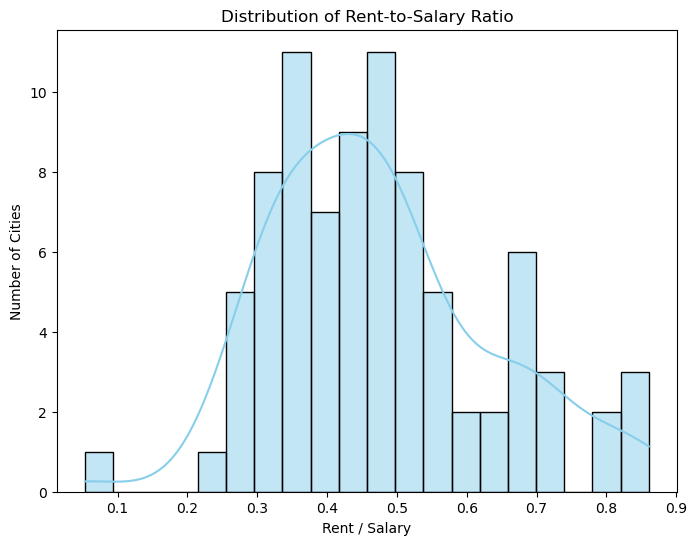

In [99]:
data_copy["rent-salary ratio"] = data_copy['Average Rent Price']/data_copy['Average Monthly Salary']
plt.figure(figsize=(8,6))
sns.histplot(data_copy["rent-salary ratio"], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Rent-to-Salary Ratio')
plt.xlabel('Rent / Salary')
plt.ylabel('Number of Cities')
plt.show()

Most cities have a `rent-salary ratio` near 0.4 and 0.5, meaning nearly half of the average salary is spent on rent. There are few cities where the ratio is really low (affordable cities) as well as some with higher ratios (with higher rent). This ratio is extremely relevant to measure the housing affordability for working individuals, since it suggests that not all cities with high `Average Monthly Salary` are truly affordable (cities with high salaries and high rents reduce the disposable income).

**Step 8**: Select the top 5 cities with the lowest and highest `Unemployment Rate`.

In [100]:
cities_low_unemployment = data_copy[['City', 'Unemployment Rate']].sort_values(by='Unemployment Rate', ascending=True)[:5]
cities_high_unemployment = data_copy[['City', 'Unemployment Rate']].sort_values(by='Unemployment Rate', ascending=False)[:5]

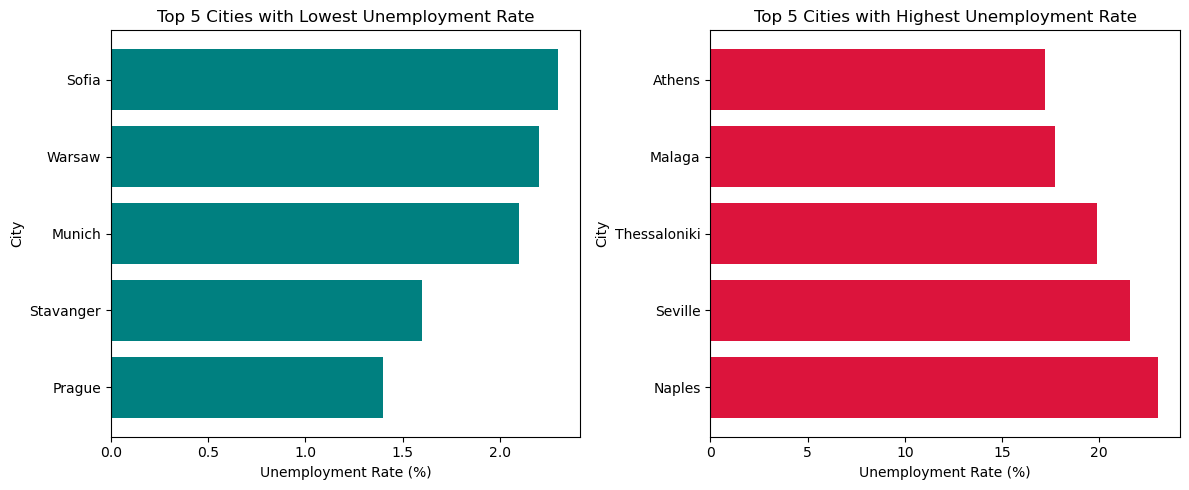

In [101]:
fig3, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].barh(cities_low_unemployment["City"], cities_low_unemployment["Unemployment Rate"], color='teal')
axs[0].set_title('Top 5 Cities with Lowest Unemployment Rate')
axs[0].set_xlabel('Unemployment Rate (%)')
axs[0].set_ylabel('City')

axs[1].barh(cities_high_unemployment["City"], cities_high_unemployment["Unemployment Rate"], color='crimson')
axs[1].set_title('Top 5 Cities with Highest Unemployment Rate')
axs[1].set_xlabel('Unemployment Rate (%)')
axs[1].set_ylabel('City')

plt.tight_layout()
plt.show()

On one hand, the cities with the lowest `Unemployment Rate` have values extremely close to 0% and under 2.5%. This is an extremely attractive insight and factor for working individuals, since it indicates more job opportunities. On the other hand, the cities with a higher `Unemployment Rate` have values over 15% with Seville and Naples exceeding 20%. This represents a major difference in the job market and job stability.

**Step 9**: Visualize the relationship between `Working Age Population` and the total `Population`.

In [102]:
data_copy['Working Age Population percentage'] = (data_copy['Working Age Population'] / data_copy['Population'])*100

In [103]:
fig = px.area(data_frame = data_copy, x = 'City', y = 'Working Age Population percentage')
fig.update_xaxes(tickmode = 'linear', dtick = 1)
fig.update_layout(
    width = 1200,   
    height = 600, 
    title_text = "Working Age Population Percentage by City",
    title_x = 0.5
)
fig.show()

Using the previous visualization, it becomes clear that it exists a data inconsistency in our dataset, since the city Dusseldorf has a `Working Age Population percentage` > 100%, meaning the Working Age Population is bigger than the total Population which is not realistic.

**Step 10**: Solve the data inconsistency by setting the `Working Age Population` to the same value as the total `Population`.

In [104]:
city_data_inconsistency = data_copy['Working Age Population'] > data_copy['Population']
data_copy.loc[city_data_inconsistency]

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update,Since Updated (in days),difference Avg. Monthly Salary and Avg. Cost of Living,rent-salary ratio,Working Age Population percentage
25,Germany,Dusseldorf,1295.0,1554077,1817524.0,21.4,3.3,71238.0,3,German,3200,1100,2050,2024-01-15,706,1150,0.34375,116.951991


In [105]:
data_copy.loc[city_data_inconsistency, 'Working Age Population'] = data_copy.loc[city_data_inconsistency, 'Population']

In [106]:
data_copy.loc[city_data_inconsistency]

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update,Since Updated (in days),difference Avg. Monthly Salary and Avg. Cost of Living,rent-salary ratio,Working Age Population percentage
25,Germany,Dusseldorf,1295.0,1554077,1554077.0,21.4,3.3,71238.0,3,German,3200,1100,2050,2024-01-15,706,1150,0.34375,116.951991


**Step 11**: Repeat the visualization to obtain accurate insights.

In [107]:
data_copy['Working Age Population percentage'] = (data_copy['Working Age Population'] / data_copy['Population'])*100
fig = px.area(data_frame = data_copy, x = 'City', y = 'Working Age Population percentage')
fig.update_xaxes(tickmode = 'linear', dtick = 1)
fig.update_layout(
    width = 1200,   
    height = 600, 
    title_text = "Working Age Population Percentage by City",
    title_x = 0.5
)
fig.show()

**NOTE**: The `Working Age Population percentage` for Dusseldorf is now corrected.

**Step 12**: Visualize the distribution of `Population` across countries based on the number of `Main Spoken Languages`.

In [108]:
# copy the dataset so we can tweak it freely
box_data = data_copy.copy()
box_data['Main Spoken Languages'] = box_data['Main Spoken Languages'].apply(lambda x: [lang.strip() for lang in x.split(',')])
box_data = box_data.groupby('Country').agg({'Main Spoken Languages': sum, 'Average Monthly Salary': 'mean'})
box_data['Main Spoken Languages'] = box_data['Main Spoken Languages'].apply(lambda x: len(set(x)))

In [138]:
fig = px.box(
    box_data.reset_index(), 
    x='Main Spoken Languages', 
    y='Average Monthly Salary',
    title='<b>Amount of Spoken Languages vs Average Monthly Salary per Country</b>',
    labels={
        'Main Spoken Languages': 'Amount of Main Spoken Languages', 
        'Average Monthly Salary': 'Avg Monthly Salary (€)'
    },
    template='plotly_white',
    color_discrete_sequence=['teal']
)
fig.update_layout(width=1200, height=600)

print(f'The amount of spoken languages and the Avg Monthly Salary in a certain country, have a moderate positive correlation of {box_data.corr().iloc[0,1].round(3)}.')
fig.show()

The amount of spoken languages and the Avg Monthly Salary in a certain country, have a moderate positive correlation of 0.403.


This plot shows the distribution of the `Average Monthly Salary` across different amounts of `Main Spoken Languages` per **Country**. There is a **moderate positive** correlation between those two variables (0.403), despite the average population seemingly lowering after the first 3 categories in the x axis. This could be due to the fact that they are both symptoms of deeper factors, namely that high-income countries attract **more immigration**, and therefore more foreign workers, or that economically strong countries are often more globalized. However, their correlation is not strong, since some countries with lower salaries are multilingual simply due to ethnic diversity or culture, and salary is influenced by many factors beyond globalization.

<a id="advanced-topic-building-an-interactive-map"></a>
### <font color='ff006e'>Advanced Topic - Building an Interactive Map</font>

<a id="web-scraping"></a>
#### <font color='ff006e'>Web Scraping</font>

**Step 1**: Define the URL to be accessed and the Selenium browser.

In [110]:
url = 'https://en.wikipedia.org/wiki/Main_Page'
options = Options_c()
browser_c = webdriver.Chrome(options = options)

**Step 2**: Create a function that extracts the coordinates for each city.

In [111]:
def coordinates(city):
    latitude, longitude = None, None
    if city=='Malta':
        try:
            url_2 = f"https://en.wikipedia.org/wiki/{city}_(island)"
            browser_c.get(url_2)

            latitude = browser_c.find_element(By.CLASS_NAME, "latitude").text
            longitude = browser_c.find_element(By.CLASS_NAME, "longitude").text
            return latitude, longitude

        except NoSuchElementException:
        # if no coordinates are found, the latitude and longitude remain as None
            print(f"Coordinates not found for {city} at second try")
    
        except Exception as e:
        # if any error arises, the latitude and longitude remain as None
            print(f"WARNING: Unexpected error during second attempt for {city}: {e}")

    try:
        city_url = f"https://en.wikipedia.org/wiki/{city.replace(' ', '_')}"
        browser_c.get(city_url)

        latitude = browser_c.find_element(By.CLASS_NAME, "latitude").text
        longitude = browser_c.find_element(By.CLASS_NAME, "longitude").text
        return latitude, longitude

    except NoSuchElementException:
        print(f"Coordinates not found for {city} at first try")
        pass

    except Exception as e:
        print(f"An unexpected error occurred for {city}: {e}")
        pass

    try:
        url_2 = f"https://en.wikipedia.org/wiki/{city}_(city)"
        browser_c.get(url_2)

        # 2nd attempt
        latitude = browser_c.find_element(By.CLASS_NAME, "latitude").text
        longitude = browser_c.find_element(By.CLASS_NAME, "longitude").text
        return latitude, longitude

    except NoSuchElementException:
        print(f"Coordinates not found for {city} at second try")
       # if any error arises, the latitude and longitude remain as None
    
    except Exception as e:
        print(f"WARNING: Unexpected error during second attempt for {city}: {e}")
        # if any error arises, the latitude and longitude remain as None
                
    try:
        url_3 = f"https://pt.wikipedia.org/wiki/{city}"
        browser_c.get(url_3)

        # 3rd attempt
        full_coord_elem = browser_c.find_element(By.CLASS_NAME, "mw-kartographer-maplink")
        coord_parts = full_coord_elem.text.split(',')
        if len(coord_parts) == 2:
            # remove unnecessary white spaces
            latitude = coord_parts[0].strip()
            longitude = coord_parts[1].strip()
            return latitude, longitude
                            
    except NoSuchElementException:
        print(f"Coordinates not found for {city} at third try")
        # if any error arises, the latitude and longitude remain as None
    
    except Exception as e:
        print(f"WARNING: Unexpected error during third attempt for {city}: {e}")
        # if any error arises, the latitude and longitude remain as None
            
    return latitude, longitude


In this function, it is crucial to note that:
- Malta's correct coordinates can only be extracted if Malta is recognized as Malta (island);
- Wikipedia URLs do not have spaces (these are replaced by underscores);
- Some cities' coordinates cannot be extracted through the standard Wikipedia page. In these cases, a second attempt is made by adding (city) to the city name;
- If both the first and second attempts fail, a third attempt is conducted, using the Portuguese version of the Wikipedia pages;
- If none of the attemps is successful, the coordinates returned are None for both latitude and longitude.

**Step 3**: Store the coordinates for each city in a dictionary.

In [112]:
list_cities = data_copy['City'].tolist()
dict_coordinates_city = {}
for city in list_cities:
    latitude, longitude = coordinates(city)
    dict_coordinates_city[city] = {'latitude': latitude, 'longitude': longitude}

res = not all(dict_coordinates_city.values())

# printing the result
print("Does the dictionary contain any None values? " + str(res))

Coordinates not found for Gent at first try
Coordinates not found for Split at first try
Coordinates not found for Cork at first try
Does the dictionary contain any None values? False


**Step 4**: Check the `dict_coordinates_city` dictionary.

In [113]:
dict_coordinates_city

{'Salzburg': {'latitude': '47°48′00″N', 'longitude': '13°02′42″E'},
 'Vienna': {'latitude': '48°12′30″N', 'longitude': '16°22′21″E'},
 'Antwerp': {'latitude': '51°13′04″N', 'longitude': '04°24′01″E'},
 'Bruges': {'latitude': '51°12′32″N', 'longitude': '03°13′27″E'},
 'Brussels': {'latitude': '50°50′48″N', 'longitude': '04°21′09″E'},
 'Gent': {'latitude': '51°03′13″N', 'longitude': '03°43′31″E'},
 'Dobrich': {'latitude': '43°34′N', 'longitude': '27°50′E'},
 'Sofia': {'latitude': '42°42′N', 'longitude': '23°20′E'},
 'Split': {'latitude': '43°30′36″N', 'longitude': '16°26′24″E'},
 'Zagreb': {'latitude': '45°48′47″N', 'longitude': '15°58′39″E'},
 'Lefkosia': {'latitude': '35°10′21″N', 'longitude': '33°21′54″E'},
 'Lemesos': {'latitude': '34°40′29″N', 'longitude': '33°02′39″E'},
 'Ostrava': {'latitude': '49°50′8″N', 'longitude': '18°17′33″E'},
 'Prague': {'latitude': '50°5′15″N', 'longitude': '14°25′17″E'},
 'Copenhagen': {'latitude': '55°40′34″N', 'longitude': '12°34′06″E'},
 'Odense': {'l

<a id="interactive-map"></a>
#### <font color='ff006e'>Interactive Map</font>

**Step 5**: Create a new DataFrame, named `city`, with the features needed for the interactive map, grouped by City and Country: `City`, `Country`, `Population`, `Average Monthly Salary`, `Average Cost of Living` and `Days of very strong heat stress`. Add to the DataFrame the latitude and longitude columns.

In [114]:
city = data_copy[data_copy.City.isin(dict_coordinates_city.keys())].groupby(['Country', 'City'])[['Population', 'Average Monthly Salary', 'Average Cost of Living', 'Days of very strong heat stress']].mean().round(2).reset_index()

city['lat'] = city['City'].map(lambda x: dict_coordinates_city[x]['latitude'])
city['lon'] = city['City'].map(lambda x: dict_coordinates_city[x]['longitude'])
city

,Country,City,Population,Average Monthly Salary,Average Cost of Living,Days of very strong heat stress,lat,lon
0,Austria,Salzburg,375489.0,3200.0,2186.0,0.0,47°48′00″N,13°02′42″E
1,Austria,Vienna,2983513.0,2500.0,2061.0,3.0,48°12′30″N,16°22′21″E
2,Belgium,Antwerp,1139663.0,2609.0,1953.0,3.0,51°13′04″N,04°24′01″E
3,Belgium,Bruges,119765.0,2700.0,1708.0,0.0,51°12′32″N,03°13′27″E
4,Belgium,Brussels,3284548.0,3350.0,1900.0,3.0,50°50′48″N,04°21′09″E
...,...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,907580.0,2500.0,2050.0,0.0,55°57′12″N,3°11′21″W
80,United Kingdom,Glasgow,1845020.0,2300.0,1950.0,0.0,55°51′40″N,04°15′00″W
81,United Kingdom,Leeds,2641062.0,2300.0,2000.0,0.0,53°47′51″N,01°32′37″W
82,United Kingdom,Liverpool,1544216.0,2250.0,1800.0,0.0,53°24′26″N,2°59′30″W


**Step 6**: Create a function to convert the coordinates from DMS format to Decimal Degrees. This is especially important since Plotly requires the coordinates to be in the latter format.

In [115]:
def dms_to_dd(dms_str):
    """
    Converts a coordinate from DMS format to Decimal Degrees.
    """
    if not isinstance(dms_str, str) or not dms_str.strip():
        return None
    
    # using regex to find degrees, minutes, seconds, and direction
    match = re.match(r"(\d+)\s*°\s*(\d*)\s*['′]?\s*(\d*\.?\d*)\s*[\"″]?\s*([NSEWO])?", dms_str.strip())
    
    if match:
        degrees = float(match.group(1))
        minutes = float(match.group(2) or 0)
        seconds = float(match.group(3) or 0)
        direction = match.group(4)
        
        # conversion formula
        dd = degrees + minutes / 60 + seconds / 3600
        
        # apply sign for South and West (Oeste/Oost)
        if direction in ('S', 'W', 'O'): 
            dd = -dd
            
        return dd
    else:
        try:
            return float(dms_str)
        except ValueError:
            return None
        
city['lat'] = city['lat'].apply(dms_to_dd)
city['lon'] = city['lon'].apply(dms_to_dd)
city

,Country,City,Population,Average Monthly Salary,Average Cost of Living,Days of very strong heat stress,lat,lon
0,Austria,Salzburg,375489.0,3200.0,2186.0,0.0,47.800000,13.045000
1,Austria,Vienna,2983513.0,2500.0,2061.0,3.0,48.208333,16.372500
2,Belgium,Antwerp,1139663.0,2609.0,1953.0,3.0,51.217778,4.400278
3,Belgium,Bruges,119765.0,2700.0,1708.0,0.0,51.208889,3.224167
4,Belgium,Brussels,3284548.0,3350.0,1900.0,3.0,50.846667,4.352500
...,...,...,...,...,...,...,...,...
79,United Kingdom,Edinburgh,907580.0,2500.0,2050.0,0.0,55.953333,-3.189167
80,United Kingdom,Glasgow,1845020.0,2300.0,1950.0,0.0,55.861111,-4.250000
81,United Kingdom,Leeds,2641062.0,2300.0,2000.0,0.0,53.797500,-1.543611
82,United Kingdom,Liverpool,1544216.0,2250.0,1800.0,0.0,53.407222,-2.991667


**Step 7**: Plot the interactive map using Plotly Express.

In [116]:
fig = px.scatter_geo(
    city,
    lat="lat",
    lon="lon",
    hover_name="City",
    hover_data={ 
        'lat': False,
        'lon': False,
        'Country': True,
        'Population': True,  
        'Average Monthly Salary': True,
        'Average Cost of Living': True  
    },
    color_discrete_sequence=["deeppink"],
    text='City'
)

fig.update_traces(
    mode='markers+text', 
    textposition='top center',
    text=[f"<b>{t}</b>" for t in city["City"]],
    textfont=dict(size=10, color='deeppink')
)

fig.update_geos(
    lataxis_range=[30, 55],
    lonaxis_range=[-15, 50],
    projection_scale=2
)
fig.update_geos(resolution=50)
fig.update_geos(
    bgcolor="lightblue",     
    landcolor="beige",
    oceancolor="lightblue",
    showland=True,
    showocean=True
)

fig.show()

**Step 8**: Create an interactive map based on `Days of very heat stress`, where each country's color represents the average number of heat stress days.

In [117]:
# aggregate information by country
df_country = city.groupby('Country', as_index=False).agg({'Population': 'mean', 'Average Monthly Salary': 'mean',	
                                                    'Average Cost of Living': 'mean', 'Days of very strong heat stress': 'mean'})
df_country['Country'] = df_country['Country'].replace('Turkiye', 'Turkey')

fig = px.choropleth(
    df_country,
    locations="Country",
    locationmode="country names",
    color="Days of very strong heat stress",   # column to drive land color
    hover_name="Country",
    scope="europe",
    projection="natural earth",
    color_continuous_scale='Agsunset',
)

fig.update_geos(
    lonaxis_range=[-10, 45],   
    lataxis_range=[35, 70],  
    projection_scale=2 
)

fig.update_geos(
    bgcolor="lightblue",
    showocean=True,
    oceancolor="lightblue"
)

fig.show()

As expected, countries like **Spain**, **France**, **Greece** and **Italy** experience (on average) a higher number of `Days of very strong heat stress`, while **Ireland**, the **United Kingdom**, **Norway**, **Finland**, **Estonia** and **Latvia** have an average of 0 days under these extreme weather.

**NOTE**: To add a creative element to this section of the project, this last map was designed. Therefore, this approach allowed for:
- the maintenance of the original, mandatory Interactive Map;
- the addition of improvements and new insights, particularly using a feature that was less explored in the previous section of the project. 

<a id="data-science-in-action"></a>
### <font color='ff006e'>Data Science in Action</font>

**Step 1**: Import the Safety Index dataset and rename the column `City` to `City,Country` in order to ensure consistency with the data_copy DataFrame. 

In [118]:
safety_index = pd.read_excel(r'safety_index.xlsx', engine='openpyxl')
safety_index = safety_index.rename(columns={'City' : 'City,Country'})

**Step 2**: Create a new `City` column using the `City, Country` column.

In [119]:
safety_index['City'] = safety_index['City,Country'].apply(lambda x: re.split(r',', x)[0])

**Step 3**: Merge the DataFrame with data_copy, mantaining all the cities from the dataset.

In [120]:
merge1 = pd.merge(data_copy, safety_index[['City,Country', 'Safety Index', 'City']], how='left', on='City')

**Step 4**: Fill the missing values in the `Safety Index` column with the mean of the index per country.

In [121]:
merge1['Safety Index'] = merge1.groupby('Country')['Safety Index'].transform(lambda s: s.fillna(s.mean()))

**Step 5**: Check remaining missing values.

In [122]:
missing = merge1['Safety Index'].isna()

print("Cities still with missing Safety Index:")
print(merge1.loc[missing, ['Country', 'City']])

Cities still with missing Safety Index:
    Country      City
10   Cyprus  Lefkosia
11   Cyprus   Lemesos
47    Malta     Malta
63  Romania     Giroc
77  Turkiye     Adana
78  Turkiye    Ankara


**Step 6**: Manually fill the missing `Safety Index` values.

In [123]:
merge1.loc[merge1['City'] == 'Lefkosia', 'Safety Index'] = 67.3
merge1.loc[merge1['City'] == 'Lemesos', 'Safety Index'] = 60.9
merge1.loc[merge1['City'] == 'Prague', 'Safety Index'] = 75.4
merge1.loc[merge1['City'] == 'Bratislava', 'Safety Index'] = 69.5
merge1.loc[merge1['City'] == 'Ankara', 'Safety Index'] = 60.5

**NOTE**: This information was acquired from https://www.numbeo.com/crime/rankings_current.jsp?displayColumn=1.

**Step 7**: Fill the missing values in the `Safety Index` column with the mean of the index per country.

In [124]:
merge1['Safety Index'] = merge1.groupby('Country')['Safety Index'].transform(lambda s: s.fillna(s.mean()))

**Step 8**: Check remaining missing values.

In [125]:
missing = merge1['Safety Index'].isna()
print("Cities still with missing Safety Index:")
print(merge1.loc[missing, ['Country', 'City']])

Cities still with missing Safety Index:
    Country   City
47    Malta  Malta
63  Romania  Giroc


**Step 9**: Manually fill the missing `Safety Index` values.

In [126]:
merge1.loc[merge1['City'] == 'Giroc', 'Safety Index'] = 74.5 # all the other cities in Romania had this index
merge1.loc[merge1['City'] == 'Malta', 'Safety Index'] = 66.7

**NOTE**: This information was acquired from https://theworldtravelindex.com/en/europe/malta/is-malta-safe.

In [127]:
missing = merge1['Safety Index'].isna()
print("Cities still with missing Safety Index:")
print(merge1.loc[missing, ['Country', 'City']])

Cities still with missing Safety Index:
Empty DataFrame
Columns: [Country, City]
Index: []


**NOTE**: All missing values for `Safety Index` were filled.

**Step 10**: Import the `education_info` dataset.

In [128]:
education_info = pd.read_excel('education_info.xlsx', 
                         sheet_name='Table 1. HDI', 
                         header=8,  
                         skiprows=0,
                         nrows=193-9)  

education_info = education_info.dropna(how='all')
education_info.columns = ['HDI_rank', 'Country', 'HDI_value', 'col3', 'Life_expectancy', 
                     'col5', 'Expected_schooling_years', 'col7', 'Mean_schooling_years',
                     'col9', 'GNI_per_capita', 'col11', 'GNI_rank_minus_HDI_rank',
                     'col13', 'HDI_rank_2022']

# columns we need
education_info = education_info[['Country',
                       'Expected_schooling_years', 'Mean_schooling_years']]

**Step 11**: Merge the DataFrame with the previous information.

In [129]:
merge2 = pd.merge(merge1, education_info, left_on='Country', right_on='Country', how='left')

**Step 12**: Create the Recomendation System.

**NOTE**: `Mean_schooling_years` was preferred over `Expected_schooling_years` as a metric for Education because it reflects actual values of the population instead of a projection.

In [130]:
features = [
    "Average Cost of Living",
    "Average Monthly Salary",
    "Safety Index",
    "Days of very strong heat stress",
    "rent-salary ratio",
    "Mean_schooling_years" 
]
scaled_data = merge2.copy()
original_data = merge2.copy()

cities = []
lats = []
lons = []

for city_name, coords in dict_coordinates_city.items():
    lat = dms_to_dd(coords['latitude'])
    lon = dms_to_dd(coords['longitude'])
    if lat is not None and lon is not None:
        cities.append(city_name)
        lats.append(lat)
        lons.append(lon)

coords_df = pd.DataFrame({
    "City": cities,
    "lat": lats,
    "lon": lons
})

scaler = MinMaxScaler()
scaled_data[features] = scaler.fit_transform(scaled_data[features])
scaled_data = scaled_data.merge(coords_df, on="City", how="left")

for col in ["Average Cost of Living", "Days of very strong heat stress", "rent-salary ratio"]: # the higher, the worst
    scaled_data[col] = 1 - scaled_data[col]

# create the sliders (with a range from 0 to 1)
cost_slider = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description='Cost:')
salary_slider = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description='Salary:')
safety_slider = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description='Safety:')
heat_slider = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description='Heat Stress:')
education_slider = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description='Education:')

def update_recommendations(cost, salary, safety, heat, education):
    # the weights are normalized (to sum up to 1)
    total = cost + salary + safety + heat + education
    if total == 0:
        weights = [0.2]*5
    else:
        weights = [cost/total, salary/total, safety/total, heat/total, education/total]
    
    user_weights = dict(zip(
        ["Average Cost of Living", "Average Monthly Salary", "Safety Index", "Days of very strong heat stress", "Mean_schooling_years"],
        weights
    ))
    
    # compute the score for each city
    scaled_data["score"] = sum(scaled_data[col] * w for col, w in user_weights.items())
    
    # select the top 10 cities
    top_cities = scaled_data.sort_values("score", ascending=False).head(10)
    
    display(top_cities[["City", "Country", "score"]])
    
    top_city_lat = top_cities.iloc[0]['lat']
    top_city_lon = top_cities.iloc[0]['lon']
    
    # this displays the results on a map
    fig = px.scatter_geo(
        top_cities,
        lat="lat",   
        lon="lon",
        size="score",
        hover_name="City",
        color="score",
        color_continuous_scale="RdPu",
        hover_data={
            'score':False,
            'lat': False,
            'lon': False,
            'Country': True,
            'Average Cost of Living': True,
            'Average Monthly Salary': True,
            'Safety Index': True,
            'Days of very strong heat stress': True,
            'Mean_schooling_years': True
                }
    )
    fig.update_geos(fitbounds="locations", resolution=110)

    fig.update_geos(
    center={"lat": top_city_lat, "lon": top_city_lon},
    projection_scale=4
)

    fig.update_geos(
        bgcolor="lightblue",
        showocean=True,
        oceancolor="lightblue"
    )

    fig.show()

widgets.interactive(
    update_recommendations,
    cost=cost_slider,
    salary=salary_slider,
    safety=safety_slider,
    heat=heat_slider,
    education=education_slider
)

interactive(children=(FloatSlider(value=0.2, description='Cost:', max=1.0, step=0.05), FloatSlider(value=0.2, …

This recomendation system displays the the **top cities** based on **user preferences**, inputed on the **sliders**. It also shows those cities on a map, color coded accordingly to each score.

For instance, if each feature is equally and of extreme concern for an individual (meaning the sliders are all set to 1.0), the system will recomend Munich as the better city (with a score of 0.8), since it is the city with lower `Average Cost of Living`, higher `Average Monthly Salary`, higher `Safety Index`, lower `Days of very strong heat stress` and higher `Mean_schooling_years`.

**Step 13**: Load the `average_temperature_df` and drop the countries that are not on `data_copy`. Group the data so that it is ready to plot.

**NOTE**: This information was acquired from: https://en.wikipedia.org/wiki/List_of_cities_by_average_temperature#Europe

In [131]:
average_temperature_df = pd.read_excel('average_temperatures.xlsx', engine='openpyxl', header=1)
average_temperature_df = average_temperature_df.dropna()
countries = data_copy['Country'].tolist()
countries_drop = average_temperature_df.loc[
    ~average_temperature_df['Country'].isin(countries)
].index
average_temperature_df = average_temperature_df.drop(countries_drop)

month_cols = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

temp_plot = average_temperature_df.melt(
    id_vars=["Country"],
    value_vars=month_cols,
    var_name="Month",
    value_name="Temperature"
)
temp_plot["Temperature"] = pd.to_numeric(
    temp_plot["Temperature"],
    errors="coerce"
)
temp_plot = temp_plot.groupby('Country')['Temperature'].agg(
        min_temperature="min",
        max_temperature="max",
        mean_temperature="mean"
    ).reset_index()

**Step 14**: Plot the graph according to the `Average Temperature` of each country.

In [132]:
fig = px.choropleth(
    temp_plot,
    locations="Country",
    locationmode="country names",
    color="mean_temperature",   # column to drive land color
    hover_name="Country",
    scope="europe",
    projection="natural earth",
    color_continuous_scale='YlOrRd',
    hover_data={'mean_temperature':True,
                'min_temperature':True,
                'max_temperature':True,
                'Country':False}
)

fig.update_geos(
    lonaxis_range=[-10, 45],   
    lataxis_range=[35, 70],  
    projection_scale=2 
)

fig.update_geos(
    bgcolor="lightblue",
    showocean=True,
    oceancolor="lightblue"
)

fig.show()

In this visualization, each country is colored according to its `Average Temperature`. As expected, countries such as **Greece**, **Spain** and **Portugal** have higher temperature values, with the first even having a maximum temperature near 30ºC. On the other hand, countries like **Norway**, **Denmark** and **Sweden** have smaller average temperatures, with the latter even having a mininum temperature near 0ºC.

**Step 15**: Aggregate the data in order to build a dashboard for comparing the different Average Temperatures accross various months.

In [133]:
temp_df = pd.merge(
    average_temperature_df,
    city[['Country', 'City', 'lat', 'lon']],
    on=['Country', 'City'],
    how='left'
)
columns = {'Year': 'Year Average Temperature'}
temp_df.rename(columns=columns, inplace=True)
temp_df.head()

,Country,City,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year Average Temperature,Ref.,lat,lon
0,Austria,Vienna,0.3,1.5,5.7,10.7,15.7,18.7,20.8,20.2,15.4,10.2,5.1,1.1,10.4,[195],48.208333,16.372500
1,Belgium,Brussels,3.3,3.7,6.8,9.8,13.6,16.2,18.4,18.0,14.9,11.1,6.8,3.9,10.5,[197],50.846667,4.352500
2,Bulgaria,Sofia,−0.5,1.1,5.4,10.6,15.4,18.9,21.2,21.0,16.5,11.3,5.1,0.7,10.6,[199],42.700000,23.333333
3,Croatia,Zagreb,0.3,2.3,6.4,10.7,15.8,18.8,20.6,20.1,15.9,10.5,5.0,1.4,10.7,[200],45.813056,15.977500
4,Croatia,Split,8.0,8.4,10.6,13.7,18.9,22.8,25.7,25.4,21.2,16.8,12.0,9.1,16.1,[201],43.510000,16.440000


**Step 16**: Create the dashboard.

In [134]:
# list of months
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for m in months:
    temp_df[m] = pd.to_numeric(temp_df[m], errors='coerce')

# --- dash ---
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Average Temperature Dashboard"),
    html.Label("Select Month:"),
    dcc.Slider(
        id='month-slider',
        min=0,
        max=11,
        step=1,
        value=0,
        marks={i: month for i, month in enumerate(months)},
    ),
    dcc.Graph(id='temperature-map')
])

# --- callback ---
@app.callback(
    Output('temperature-map', 'figure'),
    Input('month-slider', 'value')
)
def update_map(month_index):
    month = months[month_index]

    # map of cities
    figure = px.scatter_geo(
        temp_df,
        lat="lat",
        lon="lon",
        color=month,
        hover_name="City",
        hover_data={
            "Country": True,
            "City": False,
            "lat": False,
            "lon": False,
            month: True,
            'Year Average Temperature': True
            },
        color_continuous_scale="YlOrRd",
        size_max=40
    )

    figure.update_geos(fitbounds="locations")
    figure.update_geos(
    bgcolor="lightblue",       # background behind the map (ocean)
    landcolor="beige",
    oceancolor="lightblue",
    showland=True,
    showocean=True
)
    figure.update_layout(title=f"Average Temperatures - {month}")
    return figure

if __name__ == "__main__":
    app.run(debug=True, host='127.0.0.1', port=8050)
    url = "http://127.0.0.1:8050"
    Timer(1, lambda: webbrowser.open(url)).start()
    time.sleep(3)


By analysing this dashboard, it is possible to gather some insights:
- January is the coldest month overall with **Valencia** being the hottest city (12.1) and **Hamburg** the coldest (2.1).
- July is the hottest month overall with **Athens** being the hottest city (29.3) and **Edinburgh** the coldest (15.3).

**Step 17**: Load the `quality_life` dataframe and drop the countries that are not in `data_copy`.

In [135]:
quality_life = pd.read_excel('quality_of_life_index.xlsx', engine='openpyxl', header=0)
quality_life = quality_life[quality_life['Country'].isin(data_copy['Country'].unique())]
average_index = quality_life['Quality of Life Index'].mean()
quality_life

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index
0,1,Luxembourg,218.2,183.1,66.0,75.1,73.5,9.6,27.0,22.9,82.6
1,2,Netherlands,216.5,144.5,74.2,80.6,68.1,7.4,22.7,20.9,86.8
2,3,Denmark,215.1,152.7,74.0,78.3,74.1,6.1,27.7,20.9,81.2
3,4,Switzerland,210.9,183.5,73.3,70.8,106.8,10.7,34.0,24.0,80.6
4,5,Finland,208.3,142.9,73.5,77.4,64.5,7.8,25.1,11.7,54.4
5,6,Norway,199.2,133.3,67.2,75.8,78.9,8.5,26.3,18.3,70.9
7,8,Austria,197.7,122.0,71.7,78.5,67.6,11.8,23.2,20.6,76.6
8,9,Germany,195.2,144.3,60.4,71.7,64.7,8.5,29.6,28.8,82.8
9,10,Sweden,192.2,144.7,51.9,68.6,62.8,8.2,28.9,17.6,64.7
10,11,Estonia,189.8,91.5,76.5,74.8,55.9,11.1,21.4,16.9,71.2


**Step 18**: Create the function that will be used in the dashboard to plot the map and the graphs.

In [136]:
def country_map(country_name):
    """
    Receives a country name and returns its figure on the map for the following dashboard creation
    """
    cities = city[city['Country'] == country_name]

    fig = px.choropleth(
    locations=[country_name],
    locationmode="country names",
    color=[country_name],
    color_discrete_sequence=["pink"],
    scope="world")

    fig.add_scattergeo(
    lat=cities["lat"],
    lon=cities["lon"],
    text=cities["City"],
    mode="markers+text",
    name= 'Cities',
    marker=dict(
        size=8,
        color="deeppink",
        symbol="circle"
    ),
    textposition="top center",
    hoverinfo="text"
)
    fig.update_geos(
    fitbounds="locations",
    bgcolor="lightblue",
    landcolor="beige",
    oceancolor="lightblue",
    showland=True,
    showocean=True
)
    return fig

def city_graphs(country_name):
    cities_info = data_copy[data_copy['Country'] == country_name]

    df_long = cities_info.melt(
    id_vars="City",
    value_vars=["Average Monthly Salary", "Average Cost of Living"],
    var_name="Category",
    value_name="Amount"
)
    fig1 = px.bar(
        df_long,
        x='City',
        y='Amount',
        color='Category',
        barmode='group',
        title=f'Average Monthly Salary vs Average Cost of Living in {country_name}',
        color_discrete_sequence=['mediumvioletred', 'darkmagenta']
    )

    fig2 = px.bar(
        cities_info,
        x='City',
        y='Population',
        barmode='group',
        title=f'Population in {country_name}',
        color_discrete_sequence=['mediumvioletred', 'darkmagenta']
    )
    return fig1, fig2

def country_graphs(country_name):
    quality_life['selected'] = quality_life['Country'] == country_name 
    
    indexes = ['Quality of Life Index', 'Safety Index', 'Health Care Index',
               'Pollution Index','Climate Index', 'Traffic Commute Time Index']
    figs = []
    for i in indexes:
        
        df_sorted = quality_life.sort_values(by=i, ascending=False).reset_index(drop=True)
        df_sorted['Ranking'] = df_sorted.index + 1

        fig = px.scatter(
            df_sorted,
            y=i,
            x='Ranking',
            size=i,
            color='selected',
            color_discrete_map={
                True: "deeppink",
                False: "pink"
            },
            hover_data={
                'Country': True,
                i: True,
                'selected': False,
                'Rank':False,
                'Ranking': True

            },
            title=i
        )
        fig.update_layout(
        xaxis_title=None,
        xaxis_showticklabels=False,
        xaxis_showgrid=False,
        xaxis_ticks='',
        xaxis_linecolor='rgba(0,0,0,0)',
        showlegend=False,
        yaxis_title=i,
        title_x=0.5)
        figs.append(fig)
    return figs

**Step 19**: Create the dashboard using the previous functions to update it.

In [137]:
app2 = dash.Dash(__name__)

app2.layout = html.Div([
    html.H2("Country Analysis Dashboard"),
    
    html.Div([
        dcc.Input(id='country-input', type='text', placeholder='Enter country name', value=''),
        html.Button('Go', id='go-button', n_clicks=0)
    ], style={'padding': '10px'}),

    html.Div([
        dcc.Graph(id='map-graph')
    ], style={'padding': '10px'}),

    html.Div([
        dcc.Graph(id='city-graph1'),
        dcc.Graph(id='city-graph2')
    ], style={'display': 'flex', 'flex-direction': 'row', 'gap': '20px'}),

    html.Div(id='country-graphs-container', children=[
        dcc.Graph(id=f'country-graph-{i}') for i in range(6)
    ])
])


@app2.callback(
    [Output('map-graph', 'figure'),
     Output('city-graph1', 'figure'),
     Output('city-graph2', 'figure'),
     Output('country-graph-0', 'figure'),
     Output('country-graph-1', 'figure'),
     Output('country-graph-2', 'figure'),
     Output('country-graph-3', 'figure'),
     Output('country-graph-4', 'figure'),
     Output('country-graph-5', 'figure')],
    Input('go-button', 'n_clicks'),
    State('country-input', 'value')
)
def update_dashboard(n_clicks, country_name):
    if not country_name:
        return [px.scatter_geo()] * 9

    map_fig = country_map(country_name)
    city_fig1, city_fig2 = city_graphs(country_name)
    country_figs = country_graphs(country_name)
    return [map_fig, city_fig1, city_fig2] + country_figs



if __name__ == "__main__":
    app2.run(debug=True, host='127.0.0.1', port=8051)
    url = "http://127.0.0.1:8051"
    Timer(1, lambda: webbrowser.open(url)).start()


Through this dashboard, users can **select a country** by typing in its name (ex: 'Spain', 'Portugal', etc). The map zooms in on the country, and the corresponding cities are marked. Then, **2 graphs** are plotted to compare all the cities. Lastly, **6 graphs** with different indexes are displayed in relation to the country. In these graphs, the selected country is highlighted in deeppink, so individuals can easily locate the country in Europe.

For instance, if the country **Portugal** is selected, all the cities available are displayed - Lisbon, Coimbra, Porto and Braga - as well as a comparison between them in regards to `Average Monthly Salary`, `Average Cost of Living` and `Population` (in this case Lisbon is the city with the highest metrics for all those features). Additionally, the `Quality of Life Index`, `Safety Index`, `Health Care Index`, `Pollution Index`, `Climate Index` and `Traffic Commute Time Index` for the selected country are displayed. In this case, Portugal has a relatively moderate `Quality of Life Index`, with good `Safety` and `Climate` indexes and moderate `Traffic Commute Time`, `Pollution` and `Health Care` indexes. 